# MultiDense Engine — Triagem de alunos insatisfeitos com uma rede MLP — Gabriel Viana e João Victor

**Disciplina:** Redes Neurais Artificiais — Faculdade SENAI/MG

**Trabalho:** TP2 — Rede neural profunda (MLP) sobre base tabular, com TensorFlow/Keras

**Repositório:** [github.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2](https://github.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2) — base de dados, este notebook e os trabalhos anteriores que deram origem ao corpus

---

## 1. Contexto de negócio e definição do problema

**Setor:** Educação — ensino superior privado, modalidade EAD.

>No TP1 dessa disciplina havíamos optado por trabalhar com uma base de dados simulada, desenvolvida para lidar com possíveis cenários de utilização de luminárias, porém, analisando os requisitos do TP2, pudemos perceber que essa simulação não mais atendia as necessidades da tarefa, enxergamos isso como uma oportunidade de verticalizar o trabalho desenvolvido na matéria de processamento de linguagem natural, utilizando a base de dados que temos tratado nesta matéria como base aqui.

Essa mudança de setor, em especial, a mudança para uma base real, apresenta algumas questões de tratamento de dados que precisam ser consideradas; Nas avaliações de aplicativos tanto as opiniões positivas quanto as negativas estão dispostas no mesmo ambiente, para classificar essas entradas de dados variados, optamos por nos valer de um recurso nativo da própria Play Store, o sistema de estrelas, onde o sistema será treinado para associar o nível de satisfação dos comentários através da quantidade de estrelas entregue e uma vez treinado acreditamos que será capaz de ser aplicado em outros ambientes que não tenham esse tipo de classificação.

| Classe | Definição | Ação na central |
|---|---|---|
| **1 — Insatisfeito** | nota 1 ou 2 estrelas | Fila prioritária, atendimento em até 24 h |
| **0 — Não insatisfeito** | nota 3, 4 ou 5 estrelas | Fila regular |

**Métrica que importa.** O erro caro é o **falso negativo**: um aluno insatisfeito classificado como "não insatisfeito" vai para a fila regular e pode desistir antes de ser atendido. O falso positivo custa apenas antecipar o atendimento de um aluno que não precisava de prioridade. Por isso o **Recall da classe 1** será a métrica principal na Etapa D, acompanhada da Precision para controlar o volume da fila prioritária.

**Origem dos dados.** O corpus foi coletado da Google Play Store com a biblioteca `google-play-scraper` em trabalhos anteriores do curso e está congelado em um repositório público, o que garante que todas as execuções deste notebook usem exatamente os mesmos registros.

## 2. Configuração do ambiente

In [ ]:
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Semente global: toda aleatoriedade do trabalho (divisão dos dados, pesos
# iniciais da rede, embaralhamento dos lotes) parte daqui.
SEMENTE = 42
np.random.seed(SEMENTE)

# Padrão visual herdado do TP1 da disciplina
COR_C0, COR_C1 = "#2A6F97", "#D1495B"   # classe 0 (não insatisfeito) e classe 1 (insatisfeito)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})
pd.set_option("display.max_colwidth", 120)

print(f"pandas {pd.__version__} | NumPy {np.__version__} | scikit-learn {sklearn.__version__} | semente = {SEMENTE}")

pandas 3.0.2 | NumPy 2.4.4 | scikit-learn 1.8.0 | semente = 42


---
## ETAPA A — Pipeline de Preparação dos Dados

### A.1 Carga da base

In [ ]:
# Cópia congelada do corpus no repositório do trabalho (link "raw" do GitHub)
URL_BASE = "https://raw.githubusercontent.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2/main/corpus_educacao_bruto.csv"

df_bruto = pd.read_csv(URL_BASE)

print(f"Registros: {len(df_bruto):,}   Colunas: {df_bruto.shape[1]}")
display(df_bruto.head())
df_bruto.info()

Registros: 2,452   Colunas: 5


,instituicao,app_id,nota,data,texto
0,Estácio,br.estacio.estaciomobile,3,2026-09-26 01:02:34,"A interface e as funcionalidades são muito boas, mas depois da última atualização ficou lento para carregar as matér..."
1,Estácio,br.estacio.estaciomobile,1,2026-09-25 22:49:38,"tem fácil acesso as matérias e informações, porém o ""botão flutuante"" da ""ia"" fica em cima de coisas importantes e n..."
2,Estácio,br.estacio.estaciomobile,1,2026-09-25 20:48:52,Profundamente Pesado e não baixa o conteúdo para visualização Offline O aplicativo demora para abrir a única parte q...
3,Estácio,br.estacio.estaciomobile,1,2026-09-24 16:11:45,Não está aparecendo nada na tela inicial.
4,Estácio,br.estacio.estaciomobile,1,2026-09-23 23:14:06,"aplicativo horrível só trava, quase nunca abri."


<class 'pandas.DataFrame'>
RangeIndex: 2452 entries, 0 to 2451
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   instituicao  2452 non-null   str  
 1   app_id       2452 non-null   str  
 2   nota         2452 non-null   int64
 3   data         2452 non-null   str  
 4   texto        2452 non-null   str  
dtypes: int64(1), str(4)
memory usage: 95.9 KB


A base chega com cinco colunas: a instituição, o identificador do aplicativo, a nota, a data e o texto livre da manifestação. Na forma bruta, ela **não** atende ao requisito de cinco variáveis preditoras: `nota` é o alvo, `app_id` repete a instituição e quase toda a informação está concentrada em uma coluna de texto, que a rede não consegue consumir diretamente. A Seção A.4 resolve isso com engenharia de atributos. Antes, é preciso auditar a qualidade dos dados.

### A.2 Auditoria de qualidade e tratamento de nulos e inconsistências

A auditoria verifica, coluna a coluna, os problemas que corromperiam o treinamento: valores ausentes, tipos incorretos, valores fora do domínio, duplicatas, redundâncias e categorias com representação insuficiente.

In [ ]:
df = df_bruto.copy()

# ---- 1. Valores nulos ------------------------------------------------------
print("1. Valores nulos por coluna")
print(df.isna().sum().to_string(), "\n")

# ---- 2. Tipos: a data chega como texto e precisa ser convertida -----------
# errors="coerce" transforma qualquer data malformada em NaT (nulo de data),
# em vez de interromper a execução.
df["data"] = pd.to_datetime(df["data"], errors="coerce")
print(f"2. Datas inválidas após conversão ........ {df['data'].isna().sum()}")

# ---- 3. Domínio da nota ----------------------------------------------------
fora_dominio = ~df["nota"].isin([1, 2, 3, 4, 5])
print(f"3. Notas fora do domínio 1-5 ............. {fora_dominio.sum()}")

# ---- 4. Duplicatas ---------------------------------------------------------
print(f"4. Textos duplicados ...................... {df.duplicated(subset='texto').sum()}")

# ---- 5. Redundância: app_id x instituicao ----------------------------------
apps_por_inst = df.groupby("instituicao")["app_id"].nunique()
print(f"5. app_id é 1:1 com instituicao ........... {bool((apps_por_inst == 1).all())}")

# ---- 6. Representação das categorias ---------------------------------------
print("\n6. Registros por instituição")
print(df["instituicao"].value_counts().to_string())

# ---- 7. Caracteres Unicode de compatibilidade ------------------------------
alterados = df["texto"] != df["texto"].map(lambda s: unicodedata.normalize("NFKC", s))
print(f"\n7. Textos com caracteres Unicode de compatibilidade: {alterados.sum()}")
for texto in df.loc[alterados, "texto"].head(3):
    print(f"   {texto[:90]!r}")

1. Valores nulos por coluna
instituicao    0
app_id         0
nota           0
data           0
texto          0 

2. Datas inválidas após conversão ........ 0
3. Notas fora do domínio 1-5 ............. 0
4. Textos duplicados ...................... 0
5. app_id é 1:1 com instituicao ........... True

6. Registros por instituição
instituicao
Descomplica Faculdade      364
Anhanguera                 349
UNINTER                    344
Estácio                    325
UNIP                       311
Cruzeiro do Sul Virtual    272
UNIASSELVI                 252
Unopar                     226
Senac                        9

7. Textos com caracteres Unicode de compatibilidade: 5
   'O app piorou. Antes na página inicial, vc conseguia acessar a carteirinha, a grade de horá'
   'Horrível, não consigo acessar o app. Quando digito meu CPF aparece que minha matrícula não'
   '𝐞𝐬𝐭𝐮𝐝𝐨 𝐥𝐚́ 𝐚𝐩𝐫𝐞𝐧𝐝𝐢 𝐦𝐮𝐢𝐭𝐨'


**Diagnóstico e decisões de tratamento:**

1. **Nulos — nenhum.** A base já passou por higienização estrutural na coleta (remoção de avaliações sem texto e com menos de 20 caracteres). Ainda assim, o pipeline mantém a regra de tratamento explícita na próxima célula: registros sem texto ou sem nota são **descartados**, e não imputados, porque o texto é a fonte de todos os atributos e a nota é o rótulo — preencher qualquer um dos dois seria inventar o dado que o modelo precisa aprender. Assim, o notebook permanece correto se for reexecutado sobre uma coleta nova.
2. **Datas — nenhuma inválida.** A conversão com `errors="coerce"` garante que uma data malformada viraria nulo tratável, e não um erro de execução.
3. **Notas — todas no domínio 1–5.**
4. **Duplicatas — nenhuma**, também removidas na coleta.
5. **`app_id` é redundante** (cada instituição tem um único aplicativo) e será descartado: mantê-lo criaria duas colunas com a mesma informação.
6. **Categoria sub-representada:** o Senac tem apenas 9 registros, contra 226 a 364 das demais. Com 9 exemplos, divididos ainda entre treino, validação e teste, a rede não tem como aprender um padrão confiável para essa categoria — e uma coluna quase sempre zero só adiciona ruído. As categorias com menos de 30 registros são agrupadas em **"Outras"**, técnica padrão para categorias raras. Hoje o grupo contém só o Senac; com uma nova coleta, qualquer instituição pouco representada cairia nele automaticamente.
7. **Texto com caracteres de compatibilidade:** alguns alunos escrevem com letras "estilizadas" (`𝐞𝐬𝐭𝐮𝐝𝐨`) ou ordinais sobrescritos (`5⁰`). Para o computador, `𝐞` não é a letra `e`, e esses textos seriam lidos como vazios de palavras. A normalização **NFKC** converte cada caractere estilizado na letra comum equivalente.

Há ainda uma inconsistência que não aparece na auditoria: a **coluna de data está em UTC**. A biblioteca de coleta converte o horário da Play Store com `datetime.fromtimestamp`, que usa o fuso da máquina onde a coleta rodou — o Google Colab, configurado em UTC. Como os atributos de horário descrevem o comportamento do aluno brasileiro, a data é convertida para o horário de Brasília.

In [ ]:
LIMIAR_CATEGORIA_RARA = 30

# 1. Regra de nulos: descartar registros sem texto ou sem rótulo
antes = len(df)
df = df.dropna(subset=["texto", "nota"])
print(f"Registros descartados por nulo em texto/nota ....... {antes - len(df)}")

# 2. Data malformada: sem ela, os atributos de horário não podem ser calculados;
#    o registro é mantido e a data é imputada pela mediana (atributo secundário).
datas_nulas = df["data"].isna().sum()
df["data"] = df["data"].fillna(df["data"].median())
print(f"Datas imputadas pela mediana ........................ {datas_nulas}")

# 3. Nota fora do domínio: rótulo inválido, registro descartado
antes = len(df)
df = df[df["nota"].between(1, 5)]
print(f"Registros descartados por nota inválida ............. {antes - len(df)}")

# 4. Colunas redundantes
df = df.drop(columns=["app_id"])

# 5. Categorias raras agrupadas em "Outras"
contagem = df["instituicao"].value_counts()
raras = contagem[contagem < LIMIAR_CATEGORIA_RARA].index.tolist()
df["instituicao"] = df["instituicao"].where(~df["instituicao"].isin(raras), "Outras")
print(f"Instituições agrupadas em 'Outras' .................. {raras}")

# 6. Normalização Unicode NFKC
df["texto"] = df["texto"].map(lambda s: unicodedata.normalize("NFKC", s))

# 7. Fuso horário: UTC -> horário de Brasília
df["data"] = (df["data"].dt.tz_localize("UTC")
                         .dt.tz_convert("America/Sao_Paulo")
                         .dt.tz_localize(None))

df = df.reset_index(drop=True)
print(f"\nBase após tratamento: {len(df):,} registros | colunas: {list(df.columns)}")

Registros descartados por nulo em texto/nota ....... 0
Datas imputadas pela mediana ........................ 0
Registros descartados por nota inválida ............. 0
Instituições agrupadas em 'Outras' .................. ['Senac']

Base após tratamento: 2,452 registros | colunas: ['instituicao', 'nota', 'data', 'texto']


### A.3 Variável alvo

A nota de 1 a 5 é convertida no alvo binário definido na Seção 1. A nota 3 é agrupada com as positivas: uma avaliação neutra não configura o risco de evasão ou de reclamação formal que justifica a fila prioritária.

In [ ]:
df["insatisfeito"] = (df["nota"] <= 2).astype(int)

distribuicao = (
    df.groupby("nota").size().rename("registros").to_frame()
      .assign(classe=lambda d: np.where(d.index <= 2, "1 — insatisfeito", "0 — não insatisfeito"))
)
display(distribuicao)

proporcao = df["insatisfeito"].value_counts(normalize=True).sort_index()
print(f"Classe 0 — não insatisfeito : {(df['insatisfeito'] == 0).sum():>5,}  ({proporcao[0]:.1%})")
print(f"Classe 1 — insatisfeito     : {(df['insatisfeito'] == 1).sum():>5,}  ({proporcao[1]:.1%})")

,registros,classe
nota,,
1,1078,1 — insatisfeito
2,278,1 — insatisfeito
3,234,0 — não insatisfeito
4,168,0 — não insatisfeito
5,694,0 — não insatisfeito


Classe 0 — não insatisfeito : 1,096  (44.7%)
Classe 1 — insatisfeito     : 1,356  (55.3%)


As classes ficam próximas do equilíbrio (cerca de 55% contra 45%). Isso dispensa técnicas de balanceamento (sobreamostragem, pesos de classe) e torna a acurácia uma métrica legível — embora, como justificado na Seção 1, a decisão final se apoie no Recall.

> **Proibição de vazamento.** A partir daqui, a coluna `nota` só existe para gerar o alvo. Ela **nunca** entra como variável preditora: usá-la seria entregar a resposta à rede.

### A.4 Engenharia de atributos: do texto à tabela

Uma rede MLP recebe um vetor de números de tamanho fixo por registro. O texto livre precisa, portanto, ser convertido em **colunas numéricas com significado**. Cada atributo abaixo foi escolhido por uma hipótese de negócio sobre como um aluno insatisfeito escreve, e todos são interpretáveis — cada coluna pode ser lida e auditada por um gestor.

| Grupo | Atributos | Hipótese de negócio |
|---|---|---|
| **Extensão** | `n_caracteres`, `n_palavras` | Quem reclama descreve o problema em detalhe; quem elogia costuma ser breve ("Ótimo app!"). |
| **Intensidade** | `prop_maiusculas`, `n_exclamacoes`, `n_interrogacoes`, `n_alongamentos`, `n_emojis` | Caixa alta, pontuação repetida e letras alongadas ("péssimooo") marcam emoção; emojis, em avaliações, tendem a acompanhar elogios. |
| **Polaridade** | `n_termos_positivos`, `n_termos_negativos`, `n_negacoes` | Vocabulário avaliativo explícito e negações ("não abre", "nada funciona"). |
| **Tema** | `tema_financeiro`, `tema_acesso`, `tema_tecnico`, `tema_academico`, `tema_atendimento` | Cada tema corresponde a um setor da central; alguns problemas geram mais insatisfação que outros. |
| **Contexto** | `instituicao`, `periodo_dia`, `fim_de_semana` | Taxas de insatisfação diferem entre instituições; o horário da manifestação descreve o comportamento de uso. |

**Como os termos são detectados.** O texto é convertido para minúsculas e **sem acentos** antes da busca, para que `péssimo`, `PESSIMO` e `pessimo` sejam a mesma palavra — alunos escrevem com e sem acento indistintamente. Cada lista de termos é uma expressão regular com radicais (`trav\w*` cobre *trava*, *travando*, *travou*, *travamento*).

**Por que as listas são fixadas a priori.** Os termos de cada lista foram definidos pelo conhecimento do domínio, e **não** escolhidos a partir de sua correlação com o alvo. Selecionar palavras olhando quais mais separam as classes na base inteira seria uma forma de vazamento: a escolha usaria informação dos dados de teste, e o desempenho medido na Etapa D seria otimista.

In [ ]:
def sem_acentos(texto: str) -> str:
    # Minúsculas e remoção de diacríticos: 'Péssimo' -> 'pessimo'.
    decomposto = unicodedata.normalize("NFD", texto.lower())
    return "".join(c for c in decomposto if unicodedata.category(c) != "Mn")


def lexico(*termos: str) -> re.Pattern:
    # Compila uma lista de termos (com radicais \w*) em uma única regex com fronteira de palavra.
    return re.compile(r"\b(?:" + "|".join(termos) + r")\b")


# ---- Polaridade ----------------------------------------------------------------
LEXICO_POSITIVO = lexico(
    r"bom", r"boa", r"otim\w*", r"excelent\w*", r"maravilh\w*", r"perfeit\w*", r"incrive\w*",
    r"gost\w*", r"ador\w*", r"amo", r"amei", r"amando", r"recomend\w*", r"parabe\w*",
    r"facil", r"facilit\w*", r"pratic\w*", r"intuitiv\w*", r"top", r"show", r"eficien\w*",
    r"agil", r"util", r"satisfeit\w*", r"sensaciona\w*", r"fantastic\w*",
)
LEXICO_NEGATIVO = lexico(
    r"ruim", r"pessim\w*", r"horrive\w*", r"horroros\w*", r"lixo", r"pior\w*", r"porcaria",
    r"decepc\w*", r"absurd\w*", r"vergonh\w*", r"lamentave\w*", r"inaceitave\w*", r"frustr\w*",
    r"odi\w*", r"odeio", r"terrive\w*", r"precari\w*", r"descaso", r"palhacad\w*", r"inutil",
    r"desrespeit\w*", r"insatisfeit\w*", r"indignad\w*", r"revoltad\w*",
)
LEXICO_NEGACAO = lexico(r"nao", r"nunca", r"nem", r"nada", r"ninguem", r"jamais", r"nenhum\w*")

# ---- Temas (um por setor da central) ---------------------------------------------
TEMAS = {
    "tema_financeiro": lexico(
        r"boleto\w*", r"mensalidade\w*", r"pag\w*", r"cobr\w*", r"fatura\w*", r"parcela\w*",
        r"financeir\w*", r"desconto\w*", r"juros", r"multa\w*", r"dinheiro", r"reembols\w*", r"pix"),
    "tema_acesso": lexico(
        r"acess\w*", r"login", r"logar", r"logad\w*", r"loguei", r"senha\w*", r"entrar", r"entra",
        r"entro", r"entrei", r"entrando", r"cadastr\w*", r"autentic\w*", r"credencia\w*"),
    "tema_tecnico": lexico(
        r"trav\w*", r"lent\w*", r"carreg\w*", r"bug\w*", r"erro\w*", r"falh\w*", r"crash\w*",
        r"congel\w*", r"fech\w*", r"abre", r"abrir", r"abrindo", r"atualiz\w*", r"instal\w*"),
    "tema_academico": lexico(
        r"aula\w*", r"video\w*", r"conteudo\w*", r"prova\w*", r"nota\w*", r"disciplin\w*",
        r"materi\w*", r"atividade\w*", r"exercicio\w*", r"apostila\w*", r"estud\w*", r"professor\w*"),
    "tema_atendimento": lexico(
        r"suporte", r"atendiment\w*", r"atendente\w*", r"respost\w*", r"respond\w*", r"ouvidoria",
        r"tutor\w*", r"chat", r"reclam\w*", r"sac", r"secretaria", r"protocolo\w*"),
}

# ---- Intensidade -------------------------------------------------------------------
EMOJI = re.compile("[\U0001F000-\U0001FAFF☀-➿⬀-⯿]")
ALONGAMENTO = re.compile(r"([a-z])\1{2,}")      # mesma letra 3+ vezes seguidas: "muitooo"
PALAVRA = re.compile(r"[a-z]+")


def extrair_atributos(texto: str) -> dict:
    # Converte uma manifestação em um vetor de atributos numéricos interpretáveis.
    normalizado = sem_acentos(texto)
    letras = [c for c in texto if c.isalpha()]
    atributos = {
        "n_caracteres":       len(texto),
        "n_palavras":         len(PALAVRA.findall(normalizado)),
        "prop_maiusculas":    sum(c.isupper() for c in letras) / len(letras) if letras else 0.0,
        "n_exclamacoes":      texto.count("!"),
        "n_interrogacoes":    texto.count("?"),
        "n_alongamentos":     len(ALONGAMENTO.findall(normalizado)),
        "n_emojis":           len(EMOJI.findall(texto)),
        "n_termos_positivos": len(LEXICO_POSITIVO.findall(normalizado)),
        "n_termos_negativos": len(LEXICO_NEGATIVO.findall(normalizado)),
        "n_negacoes":         len(LEXICO_NEGACAO.findall(normalizado)),
    }
    for tema, padrao in TEMAS.items():
        atributos[tema] = len(padrao.findall(normalizado))
    return atributos


# Demonstração em dois registros reais (o texto mais longo e o elogio mais curto),
# antes de aplicar a extração à base inteira
exemplos = df.loc[[df["texto"].str.len().idxmax(), df.query("nota == 5")["texto"].str.len().idxmin()]]
for linha in exemplos.itertuples():
    print(f"[nota {linha.nota}] {linha.texto[:160]}...")
    print(f"   -> {extrair_atributos(linha.texto)}\n")

[nota 3] Aplicativo ótimo, para um portal, ele é bem completo, porém ele tá aparecendo muitos problemas, isso é ruim pro aluno, pois ele se prejudica bastante. Queria fa...
   -> {'n_caracteres': 500, 'n_palavras': 89, 'prop_maiusculas': 0.010126582278481013, 'n_exclamacoes': 0, 'n_interrogacoes': 0, 'n_alongamentos': 0, 'n_emojis': 0, 'n_termos_positivos': 1, 'n_termos_negativos': 2, 'n_negacoes': 2, 'tema_financeiro': 0, 'tema_acesso': 0, 'tema_tecnico': 0, 'tema_academico': 0, 'tema_atendimento': 4}

[nota 5] boa estou adquirindo...
   -> {'n_caracteres': 20, 'n_palavras': 3, 'prop_maiusculas': 0.0, 'n_exclamacoes': 0, 'n_interrogacoes': 0, 'n_alongamentos': 0, 'n_emojis': 0, 'n_termos_positivos': 1, 'n_termos_negativos': 0, 'n_negacoes': 0, 'tema_financeiro': 0, 'tema_acesso': 0, 'tema_tecnico': 0, 'tema_academico': 0, 'tema_atendimento': 0}



In [ ]:
atributos_texto = pd.DataFrame([extrair_atributos(t) for t in df["texto"]])

# ---- Atributos de contexto ----------------------------------------------------------
def periodo_do_dia(hora: int) -> str:
    # Faixas de 6 horas; o horário de uma manifestação indica o contexto de uso do aluno.
    if hora < 6:
        return "madrugada"
    if hora < 12:
        return "manha"
    if hora < 18:
        return "tarde"
    return "noite"


contexto = pd.DataFrame({
    "instituicao":   df["instituicao"],
    "periodo_dia":   df["data"].dt.hour.map(periodo_do_dia),
    "fim_de_semana": (df["data"].dt.dayofweek >= 5).astype(int),
})

base = pd.concat([atributos_texto, contexto, df["insatisfeito"]], axis=1)

ATRIBUTOS_NUMERICOS = list(atributos_texto.columns) + ["fim_de_semana"]
ATRIBUTOS_CATEGORICOS = ["instituicao", "periodo_dia"]
ALVO = "insatisfeito"

print(f"Base tabular: {base.shape[0]:,} registros x {base.shape[1] - 1} variáveis preditoras + 1 alvo")
print(f"  numéricas   ({len(ATRIBUTOS_NUMERICOS)}): {ATRIBUTOS_NUMERICOS}")
print(f"  categóricas ({len(ATRIBUTOS_CATEGORICOS)}): {ATRIBUTOS_CATEGORICOS}")
print(f"\nNulos na base tabular: {base.isna().sum().sum()}")
display(base.head())

Base tabular: 2,452 registros x 18 variáveis preditoras + 1 alvo
  numéricas   (16): ['n_caracteres', 'n_palavras', 'prop_maiusculas', 'n_exclamacoes', 'n_interrogacoes', 'n_alongamentos', 'n_emojis', 'n_termos_positivos', 'n_termos_negativos', 'n_negacoes', 'tema_financeiro', 'tema_acesso', 'tema_tecnico', 'tema_academico', 'tema_atendimento', 'fim_de_semana']
  categóricas (2): ['instituicao', 'periodo_dia']

Nulos na base tabular: 0


,n_caracteres,n_palavras,prop_maiusculas,n_exclamacoes,n_interrogacoes,n_alongamentos,n_emojis,n_termos_positivos,n_termos_negativos,n_negacoes,tema_financeiro,tema_acesso,tema_tecnico,tema_academico,tema_atendimento,instituicao,periodo_dia,fim_de_semana,insatisfeito
0,159,26,0.007634,0,0,0,0,0,0,0,0,0,3,1,0,Estácio,noite,0,0
1,276,49,0.000000,0,0,0,0,1,0,1,1,1,1,3,0,Estácio,noite,0,1
2,490,79,0.032500,1,0,0,0,0,1,3,1,0,1,2,0,Estácio,tarde,0,1
3,41,7,0.029412,0,0,0,0,0,0,2,0,0,0,0,0,Estácio,tarde,0,1
4,47,7,0.000000,0,0,0,0,0,1,1,0,0,1,0,0,Estácio,noite,0,1


In [ ]:
# Estatística descritiva dos atributos numéricos, na escala original
display(base[ATRIBUTOS_NUMERICOS].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
n_caracteres,2452.0,141.98,120.11,20.0,50.0,102.00,192.00,500.0
n_palavras,2452.0,24.23,20.74,2.0,8.0,18.00,33.00,99.0
prop_maiusculas,2452.0,0.02,0.07,0.0,0.0,0.01,0.03,1.0
n_exclamacoes,2452.0,0.28,0.87,0.0,0.0,0.00,0.00,11.0
n_interrogacoes,2452.0,0.06,0.38,0.0,0.0,0.00,0.00,8.0
n_alongamentos,2452.0,0.01,0.09,0.0,0.0,0.00,0.00,1.0
n_emojis,2452.0,0.10,0.65,0.0,0.0,0.00,0.00,12.0
n_termos_positivos,2452.0,0.56,0.86,0.0,0.0,0.00,1.00,8.0
n_termos_negativos,2452.0,0.32,0.66,0.0,0.0,0.00,0.00,5.0
n_negacoes,2452.0,1.07,1.34,0.0,0.0,1.00,2.00,9.0


A base agora é genuinamente tabular: **2.452 registros e 18 variáveis preditoras** (16 numéricas e 2 categóricas), sem nenhum valor nulo. A tabela descritiva já antecipa a necessidade de normalização: `n_caracteres` vai até 500 (limite de caracteres da Play Store), `n_palavras` passa de 90, enquanto `prop_maiusculas` e `fim_de_semana` ficam entre 0 e 1. Sem reescala, as colunas de maior amplitude dominariam as somas ponderadas dos neurônios na primeira camada.

### A.5 Divisão em treino, validação e teste

**Por que a divisão vem antes da normalização.** O enunciado lista a normalização antes da divisão, mas a ordem de *execução* precisa ser a inversa. O `MinMaxScaler` aprende o mínimo e o máximo de cada coluna; se ele for ajustado na base inteira, os limites do conjunto de teste vazam para o pré-processamento e o teste deixa de ser "cego". O mesmo vale para o `OneHotEncoder`, que aprende as categorias existentes. A regra adotada é: **dividir primeiro, ajustar os transformadores apenas no treino e aplicá-los, já ajustados, à validação e ao teste**.

**Proporções: 70% / 15% / 15%.**

| Partição | Papel |
|---|---|
| **Treino (70%)** | Ajuste dos pesos da rede e dos transformadores |
| **Validação (15%)** | Monitoramento a cada época: curva de perda e detecção de sobreajuste |
| **Teste (15%)** | Avaliação cega final, usada uma única vez na Etapa D |

Com 2.452 registros, 15% correspondem a cerca de 370 registros por partição de avaliação — suficiente para estimar Precision e Recall com estabilidade. A divisão é **estratificada** pelo alvo, para que as três partições preservem a mesma proporção de insatisfeitos. Ela é feita em dois passos: primeiro separa-se o teste (15%); depois, do restante, separa-se a validação (15/85 do restante, o que equivale a 15% do total).

In [ ]:
X = base.drop(columns=[ALVO])
y = base[ALVO].to_numpy()

X_resto, X_teste, y_resto, y_teste = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEMENTE)
X_treino, X_val, y_treino, y_val = train_test_split(
    X_resto, y_resto, test_size=0.15 / 0.85, stratify=y_resto, random_state=SEMENTE)

resumo_divisao = pd.DataFrame({
    "registros": [len(y_treino), len(y_val), len(y_teste)],
    "% do total": [len(y_treino) / len(y), len(y_val) / len(y), len(y_teste) / len(y)],
    "% insatisfeitos": [y_treino.mean(), y_val.mean(), y_teste.mean()],
}, index=["treino", "validação", "teste"])
display(resumo_divisao.style.format({"% do total": "{:.1%}", "% insatisfeitos": "{:.1%}"}))

,registros,% do total,% insatisfeitos
treino,1716,70.0%,55.3%
validação,368,15.0%,55.2%
teste,368,15.0%,55.4%


### A.6 Codificação categórica e normalização [0, 1]

As duas transformações são reunidas em um único `ColumnTransformer`, ajustado **somente no treino**:

- **Categóricas → One-Hot Encoding.** `instituicao` e `periodo_dia` não têm ordem natural: codificá-las como 0, 1, 2, … (Label Encoding) faria a rede interpretar que "UNIP" é "maior" que "Anhanguera". O One-Hot cria uma coluna binária por categoria. O parâmetro `handle_unknown="ignore"` garante que uma categoria nunca vista no treino vire um vetor de zeros, em vez de um erro. As colunas resultantes já são 0 ou 1, portanto já estão no intervalo [0, 1].
- **Numéricas → MinMaxScaler.** Cada coluna é reescalada por $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$, com $x_{\min}$ e $x_{\max}$ medidos no treino.

**A garantia do intervalo estrito.** Como os limites vêm do treino, um registro de validação ou teste pode ter um valor além do máximo visto no treino — um texto com mais exclamações do que qualquer texto de treino, por exemplo — e cairia fora de [0, 1]. O parâmetro `clip=True` limita esses valores às bordas do intervalo, cumprindo a exigência de normalização estrita sem recorrer ao ajuste na base inteira. A célula seguinte conta quantos valores foram limitados.

In [ ]:
preprocessador = ColumnTransformer(
    transformers=[
        ("numericas", MinMaxScaler(feature_range=(0, 1), clip=True), ATRIBUTOS_NUMERICOS),
        ("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ATRIBUTOS_CATEGORICOS),
    ],
    verbose_feature_names_out=False,
)

# fit SOMENTE no treino; transform nas três partições
X_treino_proc = preprocessador.fit_transform(X_treino)
X_val_proc = preprocessador.transform(X_val)
X_teste_proc = preprocessador.transform(X_teste)

NOMES_ENTRADAS = preprocessador.get_feature_names_out().tolist()
N_ENTRADAS = len(NOMES_ENTRADAS)

print(f"Variáveis preditoras antes do pré-processamento ... {X_treino.shape[1]}")
print(f"Entradas da rede após One-Hot ...................... {N_ENTRADAS}")
print(f"  {len(ATRIBUTOS_NUMERICOS)} numéricas normalizadas + "
      f"{N_ENTRADAS - len(ATRIBUTOS_NUMERICOS)} colunas binárias do One-Hot\n")
print("Colunas geradas pelo One-Hot:")
print("  ", [n for n in NOMES_ENTRADAS if n not in ATRIBUTOS_NUMERICOS])

Variáveis preditoras antes do pré-processamento ... 18
Entradas da rede após One-Hot ...................... 29
  16 numéricas normalizadas + 13 colunas binárias do One-Hot

Colunas geradas pelo One-Hot:
   ['instituicao_Anhanguera', 'instituicao_Cruzeiro do Sul Virtual', 'instituicao_Descomplica Faculdade', 'instituicao_Estácio', 'instituicao_Outras', 'instituicao_UNIASSELVI', 'instituicao_UNINTER', 'instituicao_UNIP', 'instituicao_Unopar', 'periodo_dia_madrugada', 'periodo_dia_manha', 'periodo_dia_noite', 'periodo_dia_tarde']


In [ ]:
# ---- Verificação do intervalo [0, 1] em cada partição -----------------------------
escala_numerica = preprocessador.named_transformers_["numericas"]
n_num = len(ATRIBUTOS_NUMERICOS)

print(f"{'partição':<11}{'formato':>13}{'mínimo':>9}{'máximo':>9}{'valores limitados pelo clip':>30}")
for nome, X_orig, X_proc in [("treino", X_treino, X_treino_proc),
                             ("validação", X_val, X_val_proc),
                             ("teste", X_teste, X_teste_proc)]:
    # valores que, sem o clip, teriam caído fora de [0, 1]
    bruto = (X_orig[ATRIBUTOS_NUMERICOS].to_numpy() - escala_numerica.data_min_) / escala_numerica.data_range_
    limitados = int(((bruto < 0) | (bruto > 1)).sum())
    print(f"{nome:<11}{str(X_proc.shape):>13}{X_proc.min():>9.3f}{X_proc.max():>9.3f}{limitados:>30}")

print("\nNo treino, cada coluna numérica tem mínimo exatamente 0 e máximo exatamente 1:")
print("  mínimos:", np.round(X_treino_proc[:, :n_num].min(axis=0), 12))
print("  máximos:", np.round(X_treino_proc[:, :n_num].max(axis=0), 12))

assert X_treino_proc.min() >= 0 and X_treino_proc.max() <= 1
assert X_val_proc.min() >= 0 and X_val_proc.max() <= 1
assert X_teste_proc.min() >= 0 and X_teste_proc.max() <= 1
print("\nIntervalo [0, 1] garantido nas três partições.")

partição         formato   mínimo   máximo   valores limitados pelo clip
treino        (1716, 29)    0.000    1.000                             0
validação      (368, 29)    0.000    1.000                             2
teste          (368, 29)    0.000    1.000                             0

No treino, cada coluna numérica tem mínimo exatamente 0 e máximo exatamente 1:
  mínimos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  máximos: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Intervalo [0, 1] garantido nas três partições.


### A.7 Sinal dos atributos: uma verificação antes da rede

Antes de construir a rede, vale confirmar que os atributos carregam informação sobre o alvo. O gráfico compara, **apenas no treino** e já na escala [0, 1], a média de cada atributo numérico entre as duas classes. Barras para a direita indicam atributos mais altos entre os insatisfeitos; para a esquerda, entre os não insatisfeitos. Não é um critério de seleção — todos os atributos seguem para a rede —, mas um teste de sanidade do pipeline: se nenhuma barra se afastasse de zero, a engenharia de atributos teria falhado.

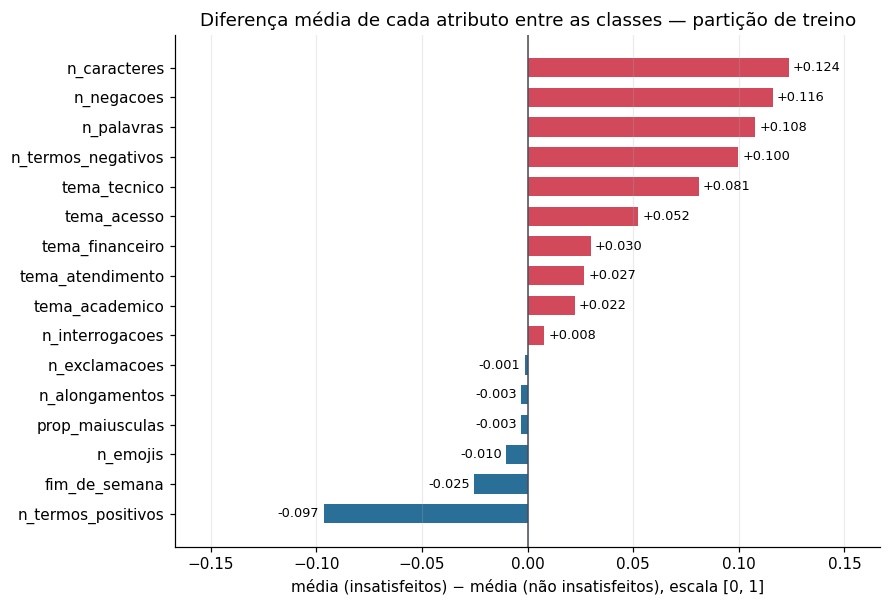

Leitura: barras vermelhas crescem com a insatisfação; barras azuis, com a satisfação.


In [ ]:
treino_num = pd.DataFrame(X_treino_proc[:, :n_num], columns=ATRIBUTOS_NUMERICOS)
diferenca = (treino_num[y_treino == 1].mean() - treino_num[y_treino == 0].mean()).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 5.6))
cores = [COR_C1 if v > 0 else COR_C0 for v in diferenca]
ax.barh(diferenca.index, diferenca.values, color=cores, height=0.65)
ax.axvline(0, color="#4A4A55", lw=1)
for i, valor in enumerate(diferenca.values):
    ax.text(valor + (0.002 if valor >= 0 else -0.002), i, f"{valor:+.3f}",
            va="center", ha="left" if valor >= 0 else "right", fontsize=8.4)
ax.set_xlabel("média (insatisfeitos) − média (não insatisfeitos), escala [0, 1]")
ax.set_title("Diferença média de cada atributo entre as classes — partição de treino")
limite = np.abs(diferenca).max() * 1.35
ax.set_xlim(-limite, limite)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

print("Leitura: barras vermelhas crescem com a insatisfação; barras azuis, com a satisfação.")

**Leitura do gráfico.** Os sinais mais fortes confirmam as hipóteses da Seção A.4: manifestações de insatisfeitos são **mais longas** (`n_caracteres`, `n_palavras`), têm **mais negações** e **mais termos negativos**, e concentram-se nos temas **técnico** e de **acesso** — aplicativo que trava, não abre ou não deixa entrar. Do outro lado, `n_termos_positivos` é o principal marcador de satisfação.

Os atributos de **intensidade** (`prop_maiusculas`, `n_exclamacoes`, `n_alongamentos`) ficaram próximos de zero: a hipótese de que caixa alta e pontuação marcariam a insatisfação não se confirmou em média. Eles são mantidos mesmo assim, por dois motivos: retirá-los com base nesse gráfico seria seleção guiada pelo alvo (a mesma forma de vazamento evitada na construção dos léxicos), e uma rede com camadas ocultas pode aproveitá-los em **interações** que uma comparação de médias não revela — exclamações podem, por exemplo, indicar insatisfação em textos longos e entusiasmo em textos curtos.

> As magnitudes não medem importância: dependem da amplitude de cada coluna no MinMax. O gráfico indica apenas a **direção** e a existência de sinal.

### A.8 Resumo da Etapa A

| Item do enunciado | Implementação |
|---|---|
| Tratamento de nulos e inconsistências | Auditoria de 7 verificações; regra de descarte para texto/nota nulos, imputação pela mediana para data, agrupamento de categoria rara, normalização Unicode NFKC, correção de fuso horário, remoção de coluna redundante |
| Codificação categórica | One-Hot Encoding em `instituicao` e `periodo_dia`, ajustado no treino |
| Normalização [0, 1] | `MinMaxScaler` ajustado no treino, com `clip=True` para garantir o intervalo em validação e teste |
| Divisão metodológica | Treino 70% / validação 15% / teste 15%, estratificada pelo alvo, antes de qualquer ajuste |

Os arrays `X_treino_proc`, `X_val_proc` e `X_teste_proc`, com `N_ENTRADAS` colunas, e os vetores de rótulos `y_treino`, `y_val` e `y_teste` são as entradas da Etapa B.